# Notebook 06 — XAI / Explicabilidade (Modelo 2: Comportamental)

Análise SHAP da Regressão Logística final do modelo comportamental. Como o modelo
é linear, usamos `LinearExplainer` (SHAP values exatos). Espera-se que as features
de atraso dominem a importância, conforme indicado pelo IV na fase de EDA.

In [ ]:
!pip install shap -q

import numpy as np
import pandas as pd
import joblib
import shap
import matplotlib.pyplot as plt
from sklearn.base import BaseEstimator, TransformerMixin

SEED = 42
MODEL_PATH = "/content/drive/MyDrive/ML_Inadimplencia_Praso/models"

# AgrupaRaras precisa estar definida para o joblib reconstruir o pipeline salvo
class AgrupaRaras(BaseEstimator, TransformerMixin):
    """Agrupa categorias com frequencia < threshold no treino em '__rara__'."""
    def __init__(self, threshold=0.05):
        self.threshold = threshold

    def fit(self, X, y=None):
        X_arr = X.values if hasattr(X, "values") else X
        self.categorias_freq_ = {}
        for col in range(X_arr.shape[1]):
            serie = pd.Series(X_arr[:, col])
            freq  = serie.value_counts(normalize=True)
            self.categorias_freq_[col] = set(freq[freq >= self.threshold].index)
        return self

    def transform(self, X):
        X_arr = (X.values if hasattr(X, "values") else X).copy().astype(object)
        for col in range(X_arr.shape[1]):
            mask = ~pd.Series(X_arr[:, col]).isin(self.categorias_freq_[col])
            X_arr[mask, col] = "__rara__"
        return X_arr

# Carrega pipeline + hold-out
model  = joblib.load(f"{MODEL_PATH}/modelo_comportamental_lr.joblib")
X_test = pd.read_parquet(f"{MODEL_PATH}/comportamental_X_test.parquet")
y_test = pd.read_parquet(f"{MODEL_PATH}/comportamental_y_test.parquet")["inadimplente"]

print(f"Pipeline carregado: {[n for n, _ in model.steps]}")
print(f"X_test : {X_test.shape}")
print(f"y_test : {y_test.shape} | inadimplencia: {y_test.mean():.1%}")

Pipeline carregado: ['prep', 'model']
X_test : (133, 36)
y_test : (133,) | inadimplencia: 21.1%


## Seção 1 — Preparação para SHAP

Aplicamos o preprocessor ao hold-out e reconstruímos os nomes das features
pós-transformação. O modelo comportamental tem três grupos numéricos
(mediana, sentinela, direto) mais as categóricas expandidas pelo OHE.

In [ ]:
prep         = model.named_steps["prep"]
linear_model = model.named_steps["model"]

# Reconstroi grupos de colunas do ColumnTransformer ja fittado
col_groups = {name: cols for name, trans, cols in prep.transformers_ if name != "remainder"}

# A ordem dos grupos no preprocessor_lr: num_mediana, num_sentinela, num_direto, cat
ordem_grupos = [t[0] for t in prep.transformers_ if t[0] != "remainder"]
print("Ordem dos grupos no preprocessor:", ordem_grupos)

# Monta nomes na ordem exata do ColumnTransformer
feat_names = []
for grupo in ordem_grupos:
    if grupo == "cat":
        ohe       = prep.named_transformers_["cat"].named_steps["ohe"]
        cat_cols  = list(col_groups["cat"])
        mapa_cat  = {f"x{i}": col for i, col in enumerate(cat_cols)}
        for n in ohe.get_feature_names_out():
            prefixo, _, valor = n.partition("_")
            feat_names.append(f"{mapa_cat.get(prefixo, prefixo)}={valor}")
    else:
        feat_names.extend(list(col_groups[grupo]))

# Transforma o hold-out
X_test_prep = prep.transform(X_test)

print(f"X_test_prep shape : {X_test_prep.shape}")
print(f"Total de nomes    : {len(feat_names)}")
assert X_test_prep.shape[1] == len(feat_names), "Mismatch entre colunas e nomes"
print("Nomes reconstruidos com sucesso.")

Ordem dos grupos no preprocessor: ['num_mediana', 'num_sentinela', 'num_direto', 'cat']
X_test_prep shape : (133, 60)
Total de nomes    : 60
Nomes reconstruidos com sucesso.


## Seção 2 — Importância Global das Features

`LinearExplainer` sobre o hold-out. Esperamos que as features de atraso
(`atraso_medio`, `prop_pedidos_atrasados`) dominem — o comportamento de pagamento
passado é o sinal mais direto de inadimplência futura.

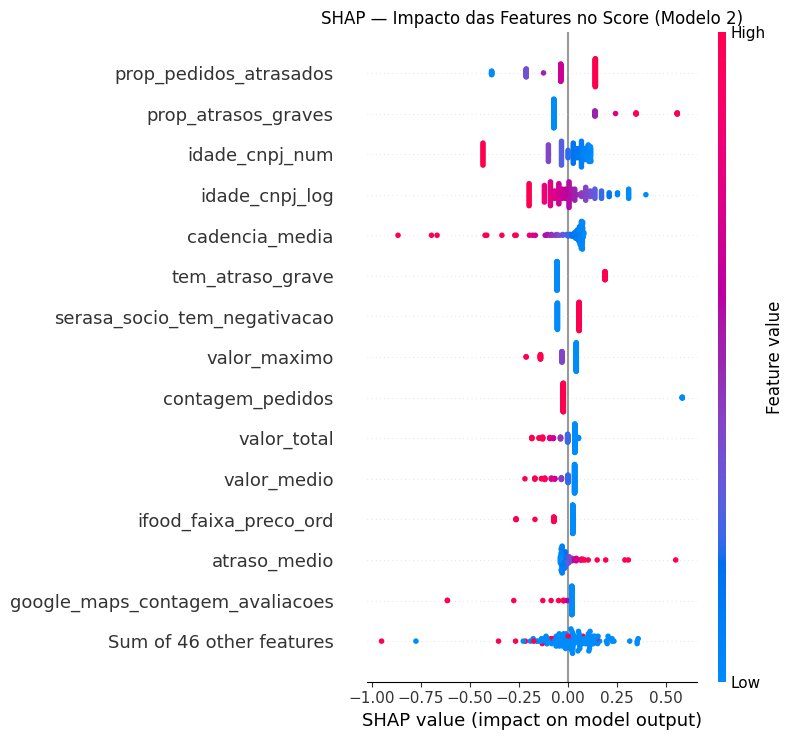

In [ ]:
explainer = shap.LinearExplainer(linear_model, X_test_prep, max_samples=X_test_prep.shape[0])
sv = explainer(X_test_prep)
sv.feature_names = feat_names

shap.plots.beeswarm(sv, max_display=15, show=False)
plt.title("SHAP — Impacto das Features no Score (Modelo 2)")
plt.tight_layout()
plt.show()

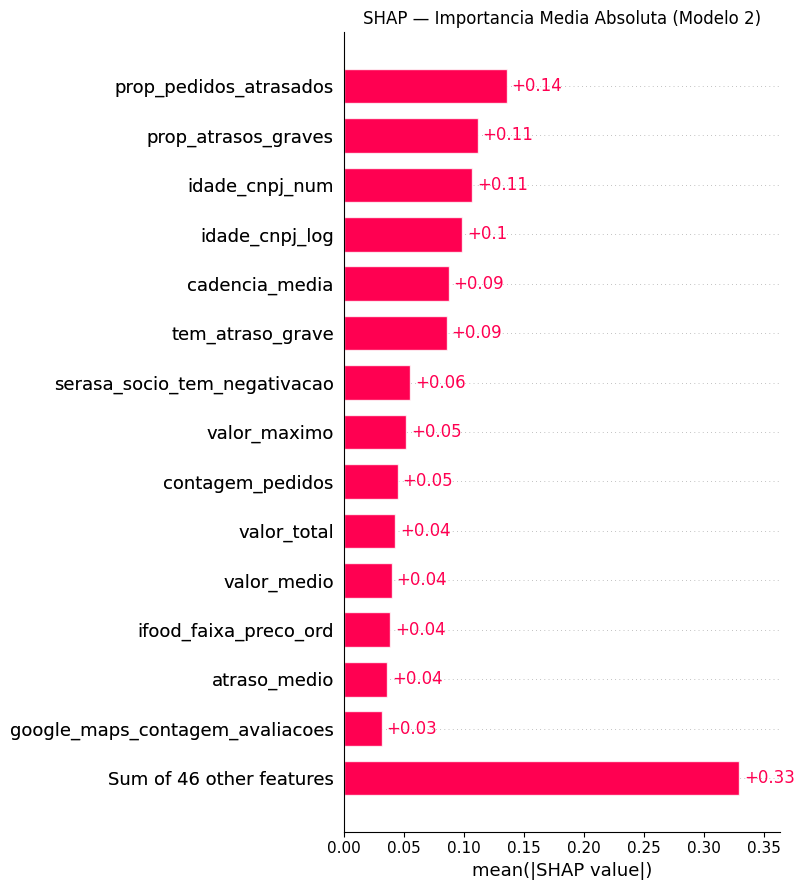

In [ ]:
shap.plots.bar(sv, max_display=15, show=False)
plt.title("SHAP — Importancia Media Absoluta (Modelo 2)")
plt.tight_layout()
plt.show()

## Seção 3 — Efeito das Top Features

Scatter plots SHAP das features mais importantes: relação entre o valor da feature
(padronizado) e o impacto no score.

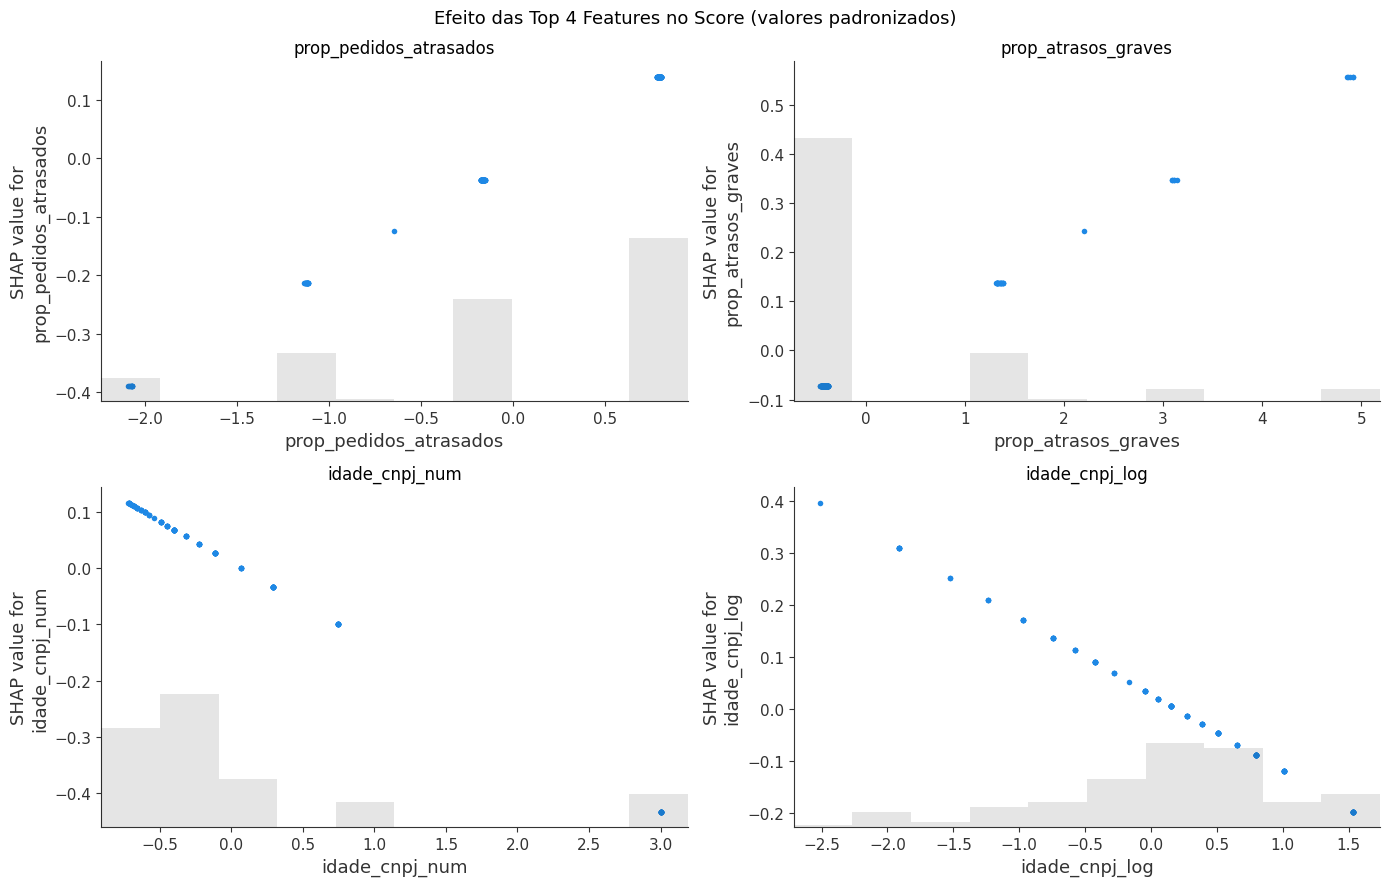

Top features por importancia SHAP:
  prop_pedidos_atrasados               importancia media: 0.1359
  prop_atrasos_graves                  importancia media: 0.1114
  idade_cnpj_num                       importancia media: 0.1071
  idade_cnpj_log                       importancia media: 0.0987


In [ ]:
importancia = np.abs(sv.values).mean(axis=0)
top_idx     = np.argsort(importancia)[::-1][:4]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, idx in zip(axes.ravel(), top_idx):
    shap.plots.scatter(sv[:, idx], ax=ax, show=False)
    ax.set_title(feat_names[idx])

plt.suptitle("Efeito das Top 4 Features no Score (valores padronizados)", fontsize=13)
plt.tight_layout()
plt.show()

print("Top features por importancia SHAP:")
for idx in top_idx:
    print(f"  {feat_names[idx]:35s}  importancia media: {importancia[idx]:.4f}")

## Seção 4 — Casos Individuais (Waterfall)

Decomposição do score de um adimplente de baixo risco e um inadimplente de alto
risco, mostrando como cada feature contribui a partir do valor base.

Caso ADIMPLENTE — score=0.085 | real=0


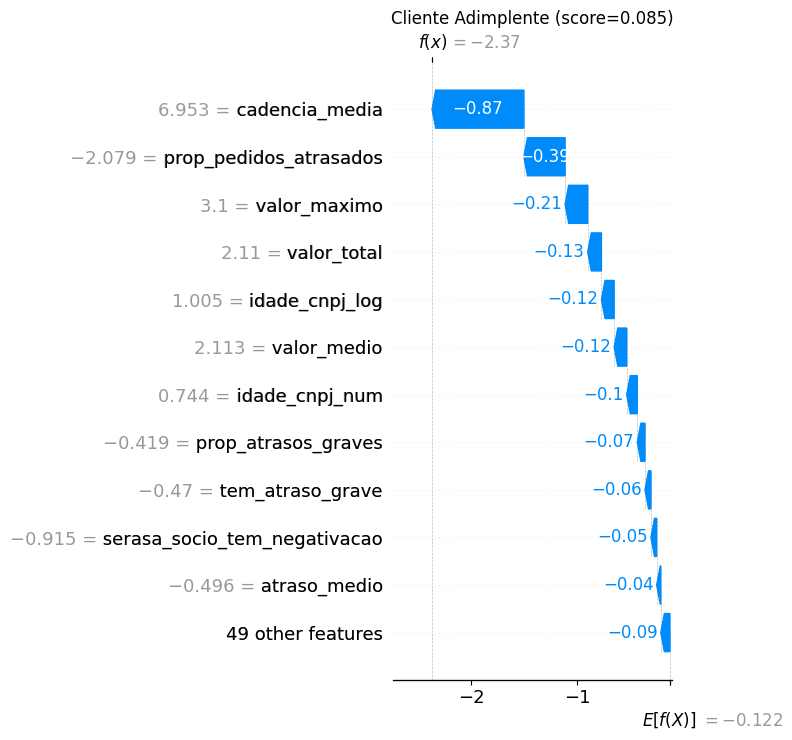

In [ ]:
y_prob = model.predict_proba(X_test)[:, 1]

idx_adim = np.where((y_test.values == 0) & (y_prob < 0.10))[0][0]
idx_inad = np.where((y_test.values == 1) & (y_prob > 0.70))[0][0]

print(f"Caso ADIMPLENTE — score={y_prob[idx_adim]:.3f} | real=0")
shap.plots.waterfall(sv[idx_adim], max_display=12, show=False)
plt.title(f"Cliente Adimplente (score={y_prob[idx_adim]:.3f})")
plt.tight_layout()
plt.show()

Caso INADIMPLENTE — score=0.853 | real=1


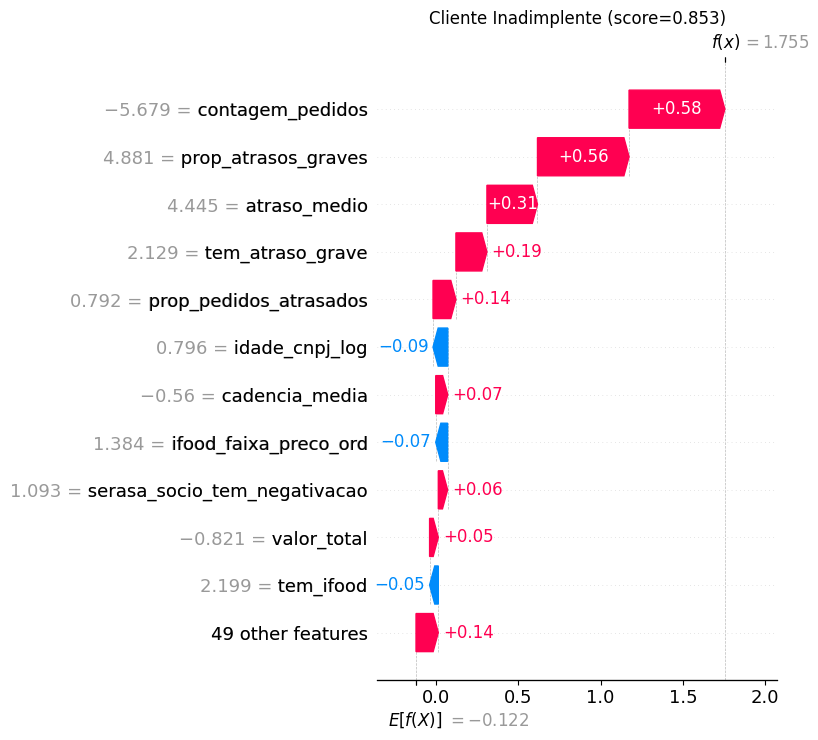

In [ ]:
print(f"Caso INADIMPLENTE — score={y_prob[idx_inad]:.3f} | real=1")
shap.plots.waterfall(sv[idx_inad], max_display=12, show=False)
plt.title(f"Cliente Inadimplente (score={y_prob[idx_inad]:.3f})")
plt.tight_layout()
plt.show()

## Seção 5 — Análise de Erros: Falsos Negativos

Falsos negativos no threshold 0.5 — inadimplentes não detectados. Como o Modelo 2
tem acesso ao histórico de atraso, espera-se que tenha menos FN "cegos" que o
Modelo 1; os erros aqui tendem a ser clientes com histórico curto ou ambíguo.

In [ ]:
thr = 0.5
y_pred  = (y_prob >= thr).astype(int)
fn_mask = (y_pred == 0) & (y_test.values == 1)
fn_idx  = np.where(fn_mask)[0]

print(f"Falsos negativos no threshold {thr}: {len(fn_idx)} clientes")
print(f"Score medio dos FN: {y_prob[fn_idx].mean():.3f}")
print()

shap_fn_medio    = np.abs(sv.values[fn_idx]).mean(axis=0)
shap_geral_medio = np.abs(sv.values).mean(axis=0)

comparacao = pd.DataFrame({
    "feature"   : feat_names,
    "shap_FN"   : shap_fn_medio,
    "shap_geral": shap_geral_medio,
}).assign(
    diff = lambda d: d["shap_FN"] - d["shap_geral"]
).sort_values("shap_FN", ascending=False).head(10)

print("Top features nos falsos negativos (vs media geral):")
print(comparacao.to_string(index=False, float_format="{:.4f}".format))

Falsos negativos no threshold 0.5: 7 clientes
Score medio dos FN: 0.403

Top features nos falsos negativos (vs media geral):
                     feature  shap_FN  shap_geral    diff
              cadencia_media   0.1615      0.0876  0.0739
      prop_pedidos_atrasados   0.1377      0.1359  0.0018
         prop_atrasos_graves   0.0723      0.1114 -0.0391
              idade_cnpj_log   0.0613      0.0987 -0.0374
            tem_atraso_grave   0.0563      0.0861 -0.0298
serasa_socio_tem_negativacao   0.0559      0.0555  0.0004
              idade_cnpj_num   0.0557      0.1071 -0.0514
                valor_maximo   0.0530      0.0523  0.0006
       ifood_faixa_preco_ord   0.0379      0.0389 -0.0011
          capital_social_log   0.0370      0.0255  0.0114


Falso negativo — score=0.493 | real=1 | threshold=0.5


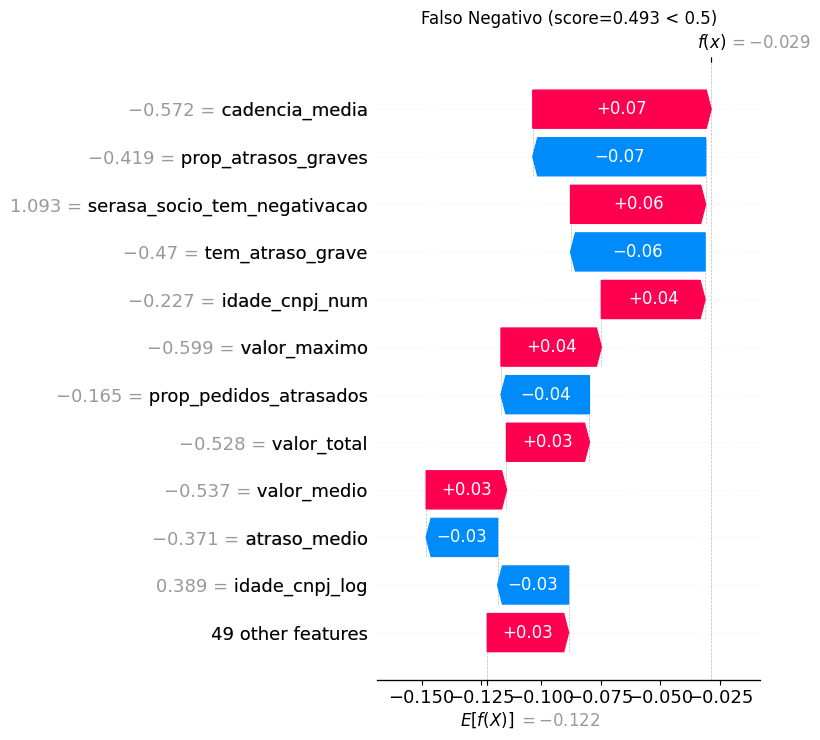

In [ ]:
if len(fn_idx) > 0:
    idx_fn = fn_idx[np.argmax(y_prob[fn_idx])]
    print(f"Falso negativo — score={y_prob[idx_fn]:.3f} | real=1 | threshold={thr}")
    shap.plots.waterfall(sv[idx_fn], max_display=12, show=False)
    plt.title(f"Falso Negativo (score={y_prob[idx_fn]:.3f} < {thr})")
    plt.tight_layout()
    plt.show()
else:
    print("Nenhum falso negativo neste threshold.")

## Conclusão — XAI do Modelo Comportamental

### Síntese da explicabilidade

A análise SHAP do modelo comportamental confirma a hipótese central que guiou todo o projeto: o comportamento de pagamento passado é o sinal mais forte de inadimplência futura. As features de atraso ocupam as primeiras posições de importância, validando empiricamente o que o Information Value (IV) já indicava na fase de análise exploratória.

- **`prop_pedidos_atrasados` (importância média 0.14)** é o preditor mais forte do modelo. O scatter plot revela relação monotônica crescente: quanto maior a fração de pedidos que o cliente atrasa, maior o score de risco.
- **`prop_atrasos_graves` (0.11)** reforça o sinal, capturando especificamente a recorrência de atrasos severos.
- **`cadencia_media` (0.09)** e **`tem_atraso_grave` (0.09)** completam o bloco comportamental dominante.

Um achado de negócio particularmente relevante emerge da comparação entre frequência e magnitude de atraso: a **frequência** de atraso (`prop_pedidos_atrasados`, importância 0.14) supera com folga a **magnitude** média (`atraso_medio`, importância 0.04). A interpretação prática é que a regularidade do comportamento de inadimplência importa mais que a severidade pontual — um cliente que atrasa sistematicamente, ainda que por poucos dias, representa risco maior que um cliente que atrasou muito em um único pedido isolado. Esse insight tem implicação direta na política de crédito: o monitoramento deve priorizar a consistência do comportamento de pagamento.

As features cadastrais (`idade_cnpj`, `serasa_socio_tem_negativacao`) aparecem em posições intermediárias — contribuem para o score, mas de forma secundária ao comportamento observado. Isso é coerente com a análise de ablação, que quantificou as features cadastrais como complemento (+0.051 AUC) e não como núcleo do poder preditivo do modelo comportamental.

### Análise de erros: limite complementar ao Modelo de Aplicação

A investigação dos falsos negativos produz o contraste mais instrutivo de todo o projeto. O modelo comportamental apresentou apenas **7 falsos negativos** no threshold 0.5, contra 45 do modelo de aplicação — uma redução expressiva que confirma a superioridade do sinal comportamental para clientes com histórico.

Mais revelador que a quantidade é a natureza desses erros. Enquanto no Modelo de Aplicação os falsos negativos eram clientes "sem sinais de alerta no cadastro", no Modelo Comportamental a feature que mais se destaca nos falsos negativos é a `cadencia_media` (impacto SHAP 0.074 acima da média do grupo). Isso indica que os erros do modelo comportamental se concentram em clientes com **histórico curto ou ainda em formação** — casos em que o padrão de atraso não teve tempo ou volume de pedidos suficiente para se manifestar de forma inequívoca. O waterfall do falso negativo representativo (score 0.493, imediatamente abaixo do threshold) confirma esse diagnóstico: as contribuições das features são pequenas e divididas, sem nenhum sinal forte de risco, justamente porque o cliente ainda não acumulou comportamento observável suficiente.

### Os dois modelos como limites complementares

A análise conjunta dos erros dos dois modelos fecha o argumento que justifica a arquitetura dupla da Praso de maneira elegante e empírica:

- O **Modelo de Aplicação** erra em clientes cujo perfil cadastral não revela risco — sua limitação é a ausência de sinal comportamental.
- O **Modelo Comportamental** erra em clientes que ainda não acumularam histórico suficiente — sua limitação é a escassez temporal de comportamento observável.

São limitações complementares, não sobrepostas. O cliente que escapa ao Modelo de Aplicação por "parecer bom no papel" é precisamente aquele que o Modelo Comportamental capturará assim que começar a atrasar pagamentos. Reciprocamente, o cliente novo que o Modelo Comportamental ainda não consegue avaliar com confiança é aquele que o Modelo de Aplicação cobre no momento do cadastro. A explicabilidade, portanto, não apenas valida cada modelo individualmente, mas demonstra que a estratégia de combiná-los — avaliação cadastral na entrada, monitoramento comportamental no acompanhamento — endereça os pontos cegos de ambos de forma estruturalmente coerente.